<a href="https://colab.research.google.com/github/nur079831-dev/Post-test/blob/main/Grafik%20Gabungan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

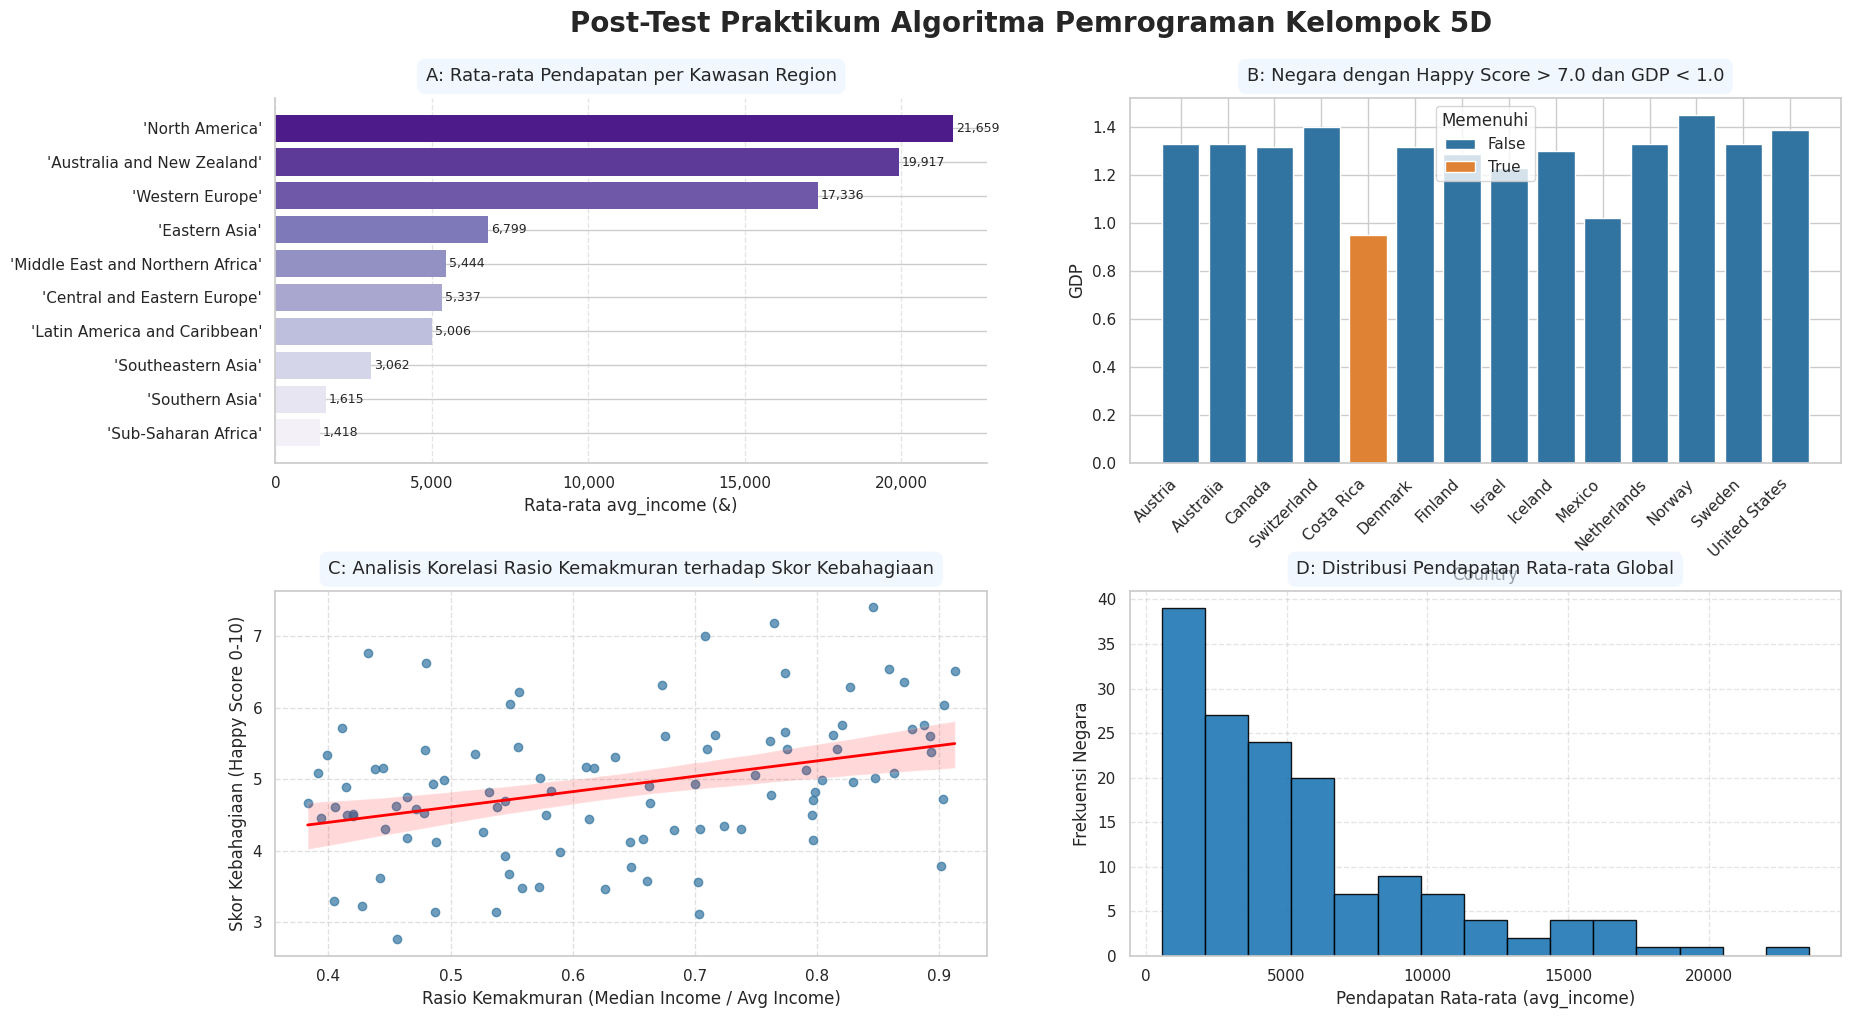

In [10]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch
import warnings

# ==============================================================================
# SECTION 1: CONFIGURATION & GENERATE DATA
# ==============================================================================

# Mengabaikan warning bawaan matplotlib agar output bersih
warnings.filterwarnings("ignore", category=UserWarning)

# Data Kategori A
regions = [
    "'North America'", "'Australia and New Zealand'", "'Western Europe'",
    "'Eastern Asia'", "'Middle East and Northern Africa'", "'Central and Eastern Europe'",
    "'Latin America and Caribbean'", "'Southeastern Asia'", "'Southern Asia'", "'Sub-Saharan Africa'"
]
avg_income = [21659, 19917, 17336, 6799, 5444, 5337, 5006, 3062, 1615, 1418]

# Data Kategori B
countries = ['Austria', 'Australia', 'Canada', 'Switzerland', 'Costa Rica', 'Denmark',
             'Finland', 'Israel', 'Iceland', 'Mexico', 'Netherlands', 'Norway', 'Sweden', 'United States']
gdp_values = [1.33, 1.33, 1.32, 1.40, 0.95, 1.32, 1.29, 1.23, 1.30, 1.02, 1.33, 1.45, 1.33, 1.39]
memenuhi = [False, False, False, False, True, False, False, False, False, False, False, False, False, False]

# Data Kategori C
np.random.seed(42)
rasio_kemakmuran = np.random.uniform(0.38, 0.92, 100)
skor_kebahagiaan = 3 + 3 * rasio_kemakmuran + np.random.normal(0, 1, 100)

# Data Kategori D
global_income = np.random.exponential(scale=5000, size=150) + 500


# ==============================================================================
# SECTION 2: CANVAS & GRID LAYOUT INITIALIZATION
# ==============================================================================

# Mengatur tema dasar seaborn agar tampilan grid terlihat bersih
sns.set_theme(style="whitegrid")

# Membuat canvas visualisasi utama
fig = plt.figure(figsize=(18, 11))
fig.suptitle("Post-Test Praktikum Algoritma Pemrograman Kelompok 5D", fontsize=20, weight='bold', y=0.96)

# Pembagian layout grid 2x2
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.2)


# ==============================================================================
# SECTION 3: PLOTTING CATEGORY A
# ==============================================================================

ax_a = fig.add_subplot(gs[0, 0])
ax_a.set_title("A: Rata-rata Pendapatan per Kawasan Region", fontsize=13, pad=12, bbox=dict(facecolor='#e6f2ff', alpha=0.6, boxstyle='round,pad=0.5'))

colors_a = sns.color_palette("Purples_r", len(regions))
bars_a = ax_a.barh(regions, avg_income, color=colors_a, edgecolor='none')
ax_a.invert_yaxis()

ax_a.set_xlabel("Rata-rata avg_income (&)")
ax_a.xaxis.set_major_formatter('{x:,.0f}')
ax_a.spines['top'].set_visible(False)
ax_a.spines['right'].set_visible(False)
ax_a.grid(axis='x', linestyle='--', alpha=0.5)

for bar in bars_a:
    width = bar.get_width()
    ax_a.text(width + 100, bar.get_y() + bar.get_height()/2, f'{width:,.0f}', va='center', ha='left', fontsize=9)


# ==============================================================================
# SECTION 4: PLOTTING CATEGORY B
# ==============================================================================

ax_b = fig.add_subplot(gs[0, 1])
ax_b.set_title("B: Negara dengan Happy Score > 7.0 dan GDP < 1.0", fontsize=13, pad=12, bbox=dict(facecolor='#e6f2ff', alpha=0.6, boxstyle='round,pad=0.5'))

colors_b = ['#e08233' if val else '#3274a1' for val in memenuhi]
bars_b = ax_b.bar(countries, gdp_values, color=colors_b)

ax_b.set_xticks(range(len(countries)))
ax_b.set_xticklabels(countries, rotation=45, ha='right')
ax_b.set_xlabel("Country")
ax_b.set_ylabel("GDP")

legend_elements = [Patch(facecolor='#3274a1', label='False'), Patch(facecolor='#e08233', label='True')]
ax_b.legend(handles=legend_elements, title="Memenuhi", loc='upper center')


# ==============================================================================
# SECTION 5: PLOTTING CATEGORY C
# ==============================================================================

ax_c = fig.add_subplot(gs[1, 0])
ax_c.set_title("C: Analisis Korelasi Rasio Kemakmuran terhadap Skor Kebahagiaan", fontsize=13, pad=12, bbox=dict(facecolor='#e6f2ff', alpha=0.6, boxstyle='round,pad=0.5'))

sns.regplot(x=rasio_kemakmuran, y=skor_kebahagiaan, ax=ax_c, scatter_kws={'alpha':0.7, 'color':'#3274a1'}, line_kws={'color':'red', 'linewidth':2})
ax_c.set_xlabel("Rasio Kemakmuran (Median Income / Avg Income)")
ax_c.set_ylabel("Skor Kebahagiaan (Happy Score 0-10)")
ax_c.grid(True, linestyle='--', alpha=0.6)


# ==============================================================================
# SECTION 6: PLOTTING CATEGORY D
# ==============================================================================

ax_d = fig.add_subplot(gs[1, 1])
ax_d.set_title("D: Distribusi Pendapatan Rata-rata Global", fontsize=13, pad=12, bbox=dict(facecolor='#e6f2ff', alpha=0.6, boxstyle='round,pad=0.5'))

ax_d.hist(global_income, bins=15, color='#1f77b4', edgecolor='black', alpha=0.9)
ax_d.set_xlabel("Pendapatan Rata-rata (avg_income)")
ax_d.set_ylabel("Frekuensi Negara")
ax_d.grid(True, linestyle='--', alpha=0.5)


# ==============================================================================
# SECTION 7: SAVE IMAGE & RENDER PLOT
# ==============================================================================

plt.subplots_adjust(top=0.88, bottom=0.1, left=0.08, right=0.95)

output_filename = "Post_Test_Kelompok_5D.png"
plt.savefig(output_filename, dpi=300, bbox_inches='tight')

plt.show()